In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import skimage.morphology as mo
from skimage import io, color #Scikit-Image
from PIL import Image # Pillow
import cv2
import os
import random
import torch # Will work on using PyTorch here later
from torch.utils.data  import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import pandas as pd
from muscle_split import Muscle 

In [47]:
tx_X = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

tx_Y = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),  # No need to normalize the mask
    # transforms.Normalize((0.5,), (0.5,))
])

train_data = Muscle(split='train', transformX=tx_X, transformY=tx_Y)
validation_data = Muscle(split='validation', transformX=tx_X, transformY=tx_Y)
test_data = Muscle(split='test', transformX=tx_X, transformY=tx_Y)

In [48]:
batch_size=8
train_loader = DataLoader(dataset = train_data, batch_size = 8, shuffle = True, num_workers = 2)
validation_loader = DataLoader(dataset = validation_data, batch_size = 8, shuffle = True, num_workers = 2)
test_loader = DataLoader(dataset = test_data, batch_size = 8, shuffle = True, num_workers = 2)
print(len(train_loader)) 
print(len(validation_loader)) 
print(len(test_loader))

51
17
17


In [49]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
def im_converterX(tensor):
    image = tensor.to(device).cpu().clone().detach().numpy() # move tensor to MPS, then to CPU and convert to numpy
    image = image.transpose(1, 2, 0) # swapping axes making (1, 28, 28) image to a (28, 28, 1)
    print("image shape is ", image.shape)
    image = image * np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)) # unnormalizing the image
    image = image.clip(0, 1) # to make sure final values are in range 0 to 1 as .ToTensor outputted
    return image

def im_converterY(tensor):
    image = tensor.to(device).cpu().clone().detach().numpy() # move tensor to MPS, then to CPU and convert to numpy
    image = image.transpose(1, 2, 0)
    print("image shape is ", image.shape)
    image = image * np.array((1, 1, 1))
    image = image.clip(0, 1)
    return image

0 torch.Size([8, 3, 256, 256]) torch.Size([8, 1, 256, 256])
image shape is  (256, 256, 3)
image shape is  (256, 256, 1)
image shape is  (256, 256, 3)
image shape is  (256, 256, 1)


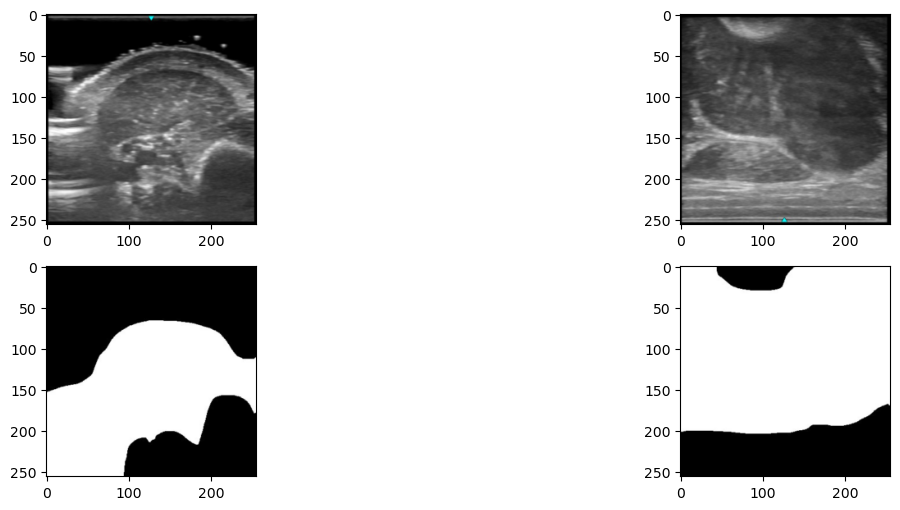

In [50]:
fig = plt.figure(figsize = (15,6))
for ith_batch, sample_batched in enumerate(train_loader):
    print(ith_batch, sample_batched['image'].size(), sample_batched['mask'].size())
    for index in range(2):
        ax = fig.add_subplot(2, 2 , index + 1)  # subplot index starts from 1
        plt.imshow(im_converterX(sample_batched['image'][index]))
        ax = fig.add_subplot(2, 2, index + 3)
        plt.imshow(im_converterY(sample_batched['mask'][index]))
    break

In [51]:
class double_conv(nn.Module):
  '''(conv => BN => ReLU) * 2'''
  def __init__(self, in_ch, out_ch):
    super(double_conv, self).__init__()
    self.conv = nn.Sequential(
      nn.Conv2d(in_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      nn.ReLU(inplace=True),
      nn.Conv2d(out_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      nn.ReLU(inplace=True)
    )

  def forward(self, x):
    x = self.conv(x)
    return x

class inconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(inconv, self).__init__()
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x):
    x = self.conv(x)
    return x

class down(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(down, self).__init__()
    self.mpconv = nn.Sequential(
        nn.MaxPool2d(2),
        double_conv(in_ch, out_ch)
    )

  def forward(self, x):
    x = self.mpconv(x)
    return x

class up(nn.Module):
  def __init__(self, in_ch, out_ch, bilinear=True):
    super(up, self).__init__()
    self.up = nn.Upsample(
      scale_factor=2, mode='bilinear', align_corners=True)
    self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x1, x2):
    x1 = self.up(x1)
    diff1 = x2.shape[2]-x1.shape[2]
    diff2 = x2.shape[3]-x1.shape[3]
    x1 = F.pad(x1, pad=(diff1//2, diff1-diff1//2, diff2//2, diff2-diff2//2))
    x = torch.cat([x2, x1], dim=1)
    x = self.conv(x)
    return x

class outconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(outconv, self).__init__()
    self.conv = nn.Conv2d(in_ch, out_ch, 1)

  def forward(self, x):
    x = self.conv(x)
    return x

In [52]:
class UNet(nn.Module):
  def __init__(self, n_channels, n_classes):
    super(UNet, self).__init__()
    self.inc = inconv(n_channels, 64)
    self.down1 = down(64, 128)
    self.down2 = down(128, 256)
    self.down3 = down(256, 512)
    self.down4 = down(512, 512)
    self.up1 = up(1024, 256, bilinear = False)
    self.up2 = up(512, 128, bilinear = False)
    self.up3 = up(256, 64, bilinear = False)
    self.up4 = up(128, 64, bilinear = False)
    self.outc = outconv(64, n_classes)
    self.dropout = torch.nn.Dropout2d(0.5)

  def forward(self, x):
    x = x.float()
    x1 = self.inc(x)
    x2 = self.down1(x1)
    x3 = self.down2(x2)
    x4 = self.down3(x3)
    x5 = self.down4(x4)
    x = self.up1(x5, x4)
    x = self.up2(x, x3)
    x = self.dropout(x)
    x = self.up3(x, x2)
    x = self.up4(x, x1)
    x = self.outc(x)
    return torch.sigmoid(x)

In [53]:
model = UNet(3, 1)
model.to(device)
print(f"Model Loaded to {device}")

Model Loaded to mps


In [54]:
criterion = nn.BCELoss() # BCE = Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01) # lr = learning rate

In [55]:
# calculates similarity index between predicted and actual segmentation
def dice_index(y_pred, y_actual):
  smooth = 0.000001 # prevent division by 0
  size_of_batch = y_pred.size(0)
  p1 = y_pred.view(size_of_batch, -1)
  p2 = y_actual.view(size_of_batch, -1)
  intersection = (p1 * p2).sum()
  dice =  ((2.0 * intersection )+ smooth) / (p1.sum() + p2.sum() + smooth)
  return dice

# calculate dice loss which will be later used in loss function calculation
def dice_loss(y_predict, y_train): ## to add in bce looss
  return 1 -(dice_index(y_predict, y_train))

In [56]:
epochs = 40  # number of iterations of the training dataset during the training process

train_running_loss_history = []
validation_running_loss_history = []

# Check if MPS is available and set the device
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

model.to(device)

for e in range(epochs):
    train_running_loss = 0.0
    validation_running_loss = 0.0
    model.train()
    for ith_batch, sample_batched in enumerate(train_loader):
        X_train = sample_batched['image'].to(device)
        y_train = sample_batched['mask'].to(device)  # hayo: make the weight to device
        optimizer.zero_grad()
        y_pred = model(X_train)  # hayo: Input type and weight type should be the same
        loss = 0.30 * dice_loss(y_pred, y_train) + 0.70 * criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        if ith_batch % 5 == 0:
            print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())
        train_running_loss += loss.item()
    else:
        with torch.no_grad():
            model.eval()
            for ith_batch, sample_batched in enumerate(validation_loader):
                X_val = sample_batched['image'].to(device)
                y_val = sample_batched['mask'].to(device)
                y_out = model(X_val)
                out_val = (y_out + 0.5).int().float()
                val_loss = 0.3 * dice_loss(out_val, y_val) + 0.7 * criterion(y_out, y_val)
                validation_running_loss += val_loss.item()
            print("================================================================================")
            print("Epoch {} completed".format(e + 1))

            train_epoch_loss = train_running_loss / len(train_loader)
            validation_epoch_loss = validation_running_loss / len(validation_loader)

            print("Average train loss is {}: ".format(train_epoch_loss))
            print("Average validation loss is {}".format(validation_epoch_loss))
            print("================================================================================")
            train_running_loss_history.append(train_epoch_loss)
            validation_running_loss_history.append(validation_epoch_loss)

    torch.mps.empty_cache() if device.type == 'mps' else torch.cuda.empty_cache()

Epoch:  1 Batch:  0 Current Loss:  0.6317670345306396
Epoch:  1 Batch:  5 Current Loss:  0.5604716539382935
Epoch:  1 Batch:  10 Current Loss:  0.5070111155509949
Epoch:  1 Batch:  15 Current Loss:  0.45725637674331665
Epoch:  1 Batch:  20 Current Loss:  0.5300440192222595
Epoch:  1 Batch:  25 Current Loss:  0.49852830171585083
Epoch:  1 Batch:  30 Current Loss:  0.4067073166370392
Epoch:  1 Batch:  35 Current Loss:  0.4151117205619812
Epoch:  1 Batch:  40 Current Loss:  0.5448303818702698
Epoch:  1 Batch:  45 Current Loss:  0.42832106351852417
Epoch:  1 Batch:  50 Current Loss:  0.3860676884651184
Epoch 1 completed
Average train loss is 0.48990216675926657: 
Average validation loss is 0.5898805067819708
Epoch:  2 Batch:  0 Current Loss:  0.3541625440120697
Epoch:  2 Batch:  5 Current Loss:  0.422105073928833
Epoch:  2 Batch:  10 Current Loss:  0.49515867233276367
Epoch:  2 Batch:  15 Current Loss:  0.3902133107185364
Epoch:  2 Batch:  20 Current Loss:  0.3607358932495117
Epoch:  2 Bat

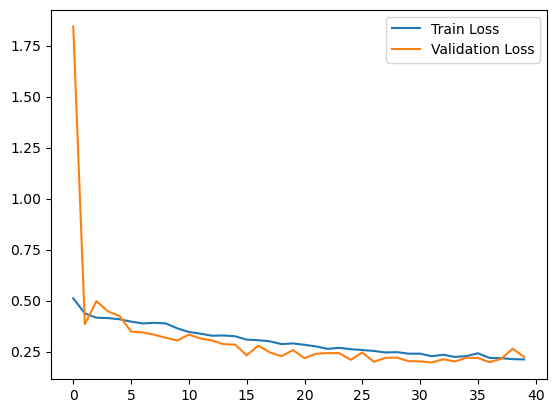

In [ ]:
plt.plot(train_running_loss_history, label = 'Train Loss')
plt.plot(validation_running_loss_history, label = 'Validation Loss')
plt.legend()

In [ ]:
model.eval()

UNet(
  (inc): inconv(
    (conv): double_conv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
  )
  (down1): down(
    (mpconv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): double_conv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2

In [ ]:
def avg_dice_index(dataloader):
    dice = 0.0
    model.eval()
    model.to(device)
    with torch.no_grad():
        for ith_batch, sample_batched in enumerate(dataloader):
            X_train = sample_batched['image'].to(device)
            y_train = sample_batched['mask'].to(device)
            y_predict = (model(X_train) + 0.5).int().float()
            dice += dice_index(y_predict, y_train)
    avg_dice = dice / len(dataloader)
    return avg_dice.item()

In [ ]:
avg_dice_index(validation_loader)

0.8755000233650208

In [ ]:
avg_dice_index(train_loader)

0.8674286007881165

In [ ]:
avg_dice_index(test_loader)

In [ ]:
local_file_path = 'Learn_Unet.pt'

torch.save(model, local_file_path)

model = torch.load(local_file_path)

# Check if MPS is available and set the device
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# Move the model to the appropriate device
model.to(device)
model.eval()

UNet(
  (inc): inconv(
    (conv): double_conv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
  )
  (down1): down(
    (mpconv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): double_conv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2